In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
data = np.loadtxt("dataCircle.txt")
print(data)

[[ 0.       0.       1.     ]
 [-3.70962 -5.3521   1.     ]
 [-1.42211 -2.40219  1.     ]
 [-2.66972  4.30397  1.     ]
 [ 1.55548  4.9359   1.     ]
 [-1.59524  6.23187  1.     ]
 [-5.55343 -1.67754  1.     ]
 [-5.57887 -0.37315  1.     ]
 [ 2.91409  4.75527  1.     ]
 [-1.92258 -5.99233  1.     ]
 [ 4.57485  4.59031  1.     ]
 [ 5.32024 -0.0782   1.     ]
 [ 1.98235 -1.70504  1.     ]
 [-1.67116  2.00863  1.     ]
 [ 2.39138  0.11597  1.     ]
 [-0.03928 -2.43152  1.     ]
 [ 1.29275 -1.86318  1.     ]
 [ 0.01739  0.86042  1.     ]
 [-0.14444 -4.24898  1.     ]
 [ 6.38276  1.80984  1.     ]
 [ 2.33197 -4.20321  1.     ]
 [-6.6919   1.80744  1.     ]
 [-2.67265 -0.99825  1.     ]
 [-5.1902  -2.51251  1.     ]
 [ 5.7403  -0.70631  1.     ]
 [ 2.73013 -3.54386  1.     ]
 [-4.75332  2.13464  1.     ]
 [ 2.0199   0.78374  1.     ]
 [ 2.07486  4.42268  1.     ]
 [-5.04006  1.98926  1.     ]
 [-1.5867  -3.00892  1.     ]
 [ 0.25811  6.21287  1.     ]
 [ 3.82225  0.48971  1.     ]
 [ 3.46025

In [29]:
X = data[:, 0:2]
Y = data[:,2]

n_muestras = len(X)
print(n_muestras)

102


Aciertos totales del modelo 91
Parametros encontrados:
Eje: 0, Umbral: 4.68591, Polaridad: -1, Alpha: 0.2397865401309428
Eje: 0, Umbral: 9.99208, Polaridad: 1, Alpha: 0.3315382888559619
Eje: 0, Umbral: -5.57887, Polaridad: 1, Alpha: 0.4008820414648118
Eje: 0, Umbral: -9.79845, Polaridad: -1, Alpha: 0.26373167770031586
Eje: 1, Umbral: 6.45953, Polaridad: -1, Alpha: 0.3791267816721245


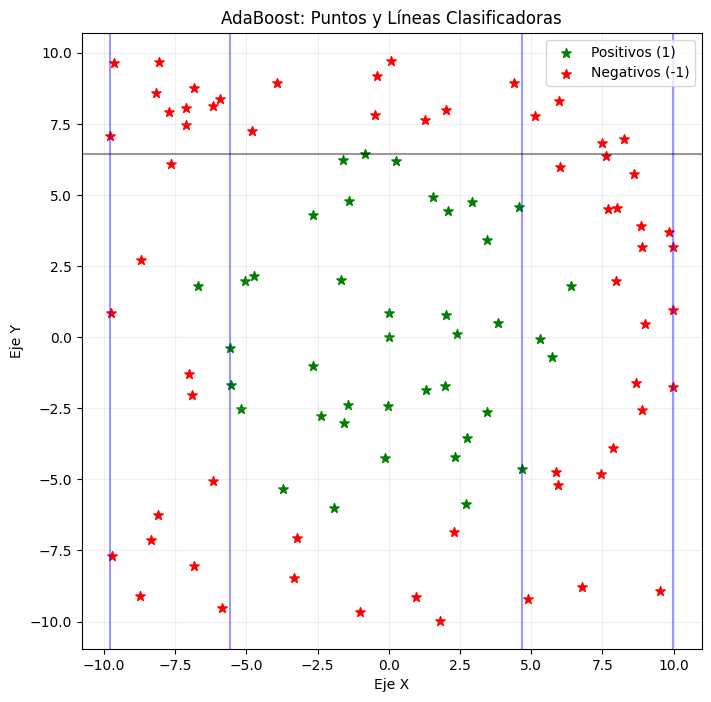

In [53]:
n_clasificadores = 5
w = np.full(n_muestras, 1.0 / n_muestras)

lineas_eje = []
lineas_umbral = []
lineas_polaridad = []
lineas_alpha = []

for t in range(n_clasificadores):
  mejor_error = float('inf')
  mejor_eje = 0
  mejor_umbral = 0
  mejor_polaridad = 1
  mejor_prediccion = np.zeros(n_muestras)

  for eje in [0, 1]:
    valores_columna = X[:, eje]

    for umbral in np.unique(valores_columna):
      for polaridad in [1, -1]:
        prediccion = np.ones(n_muestras)
        if polaridad == 1:
            prediccion[valores_columna < umbral] = -1
        else:
            prediccion[valores_columna > umbral] = -1
        error = np.sum(w[Y != prediccion])

        if error < mejor_error:
                    mejor_error = error
                    mejor_eje = eje
                    mejor_umbral = umbral
                    mejor_polaridad = polaridad
                    mejor_prediccion = prediccion
  alpha = 0.5 * np.log((1.0 - mejor_error) / mejor_error)
  w = w * np.exp(-alpha * Y * mejor_prediccion)
  w = w / np.sum(w)

  lineas_eje.append(mejor_eje)
  lineas_umbral.append(mejor_umbral)
  lineas_polaridad.append(mejor_polaridad)
  lineas_alpha.append(alpha)

votos_totales = np.zeros(n_muestras)

for t in range(n_clasificadores):
  pred_individual = np.ones(n_muestras)
  valores_columna = X[:, lineas_eje[t]]
  if lineas_polaridad[t] == 1:
      pred_individual[valores_columna < lineas_umbral[t]] = -1
  else:
      pred_individual[valores_columna > lineas_umbral[t]] = -1

  votos_totales += lineas_alpha[t] * pred_individual

prediccion_final = np.sign(votos_totales)
aciertos = np.sum(prediccion_final == Y)
print('Aciertos totales del modelo', aciertos)


plt.figure(figsize=(8, 8))

plt.scatter(X[Y == 1][:, 0], X[Y == 1][:, 1], color='green', marker='*', s=50, label='Positivos (1)')
plt.scatter(X[Y == -1][:, 0], X[Y == -1][:, 1], color='red', marker='*', s=50, label='Negativos (-1)')

print("Parametros encontrados:")
for t in range(n_clasificadores):
    print(f"Eje: {lineas_eje[t]}, Umbral: {lineas_umbral[t]}, Polaridad: {lineas_polaridad[t]}, Alpha: {lineas_alpha[t]}")
    if lineas_eje[t] == 0:
        plt.axvline(x=lineas_umbral[t], color='blue', alpha=0.4)
    else:
        plt.axhline(y=lineas_umbral[t], color='black', alpha=0.4)
plt.xlabel("Eje X")
plt.ylabel("Eje Y")
plt.title("AdaBoost: Puntos y Líneas Clasificadoras")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

Codigo: https://colab.research.google.com/drive/1Jf_MoL4rRHIMHEZ78x_RISIBHxLF2zfv?usp=sharing